In [309]:
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from anytree import Node, RenderTree, PreOrderIter, AsciiStyle

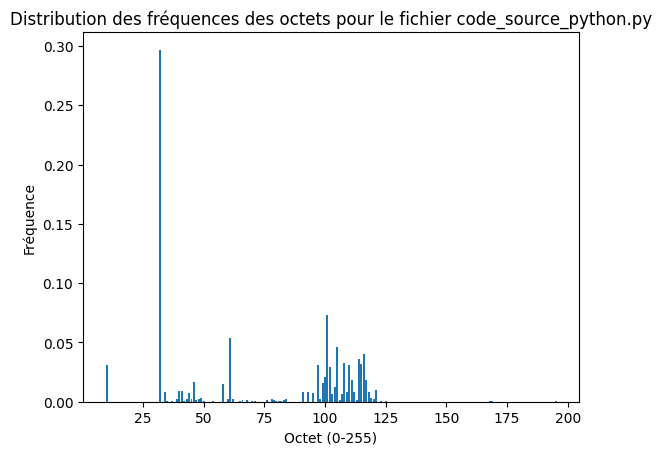

=== Analyse de code_source_python.py ===
  taille_octets: 3844
  entropie: 4.368
  economie_max_h0: 45.41
  longueur_plage_max: 78
  longueur_plage_moy: 1.33
  couverture_motifs_4grams: 100.0


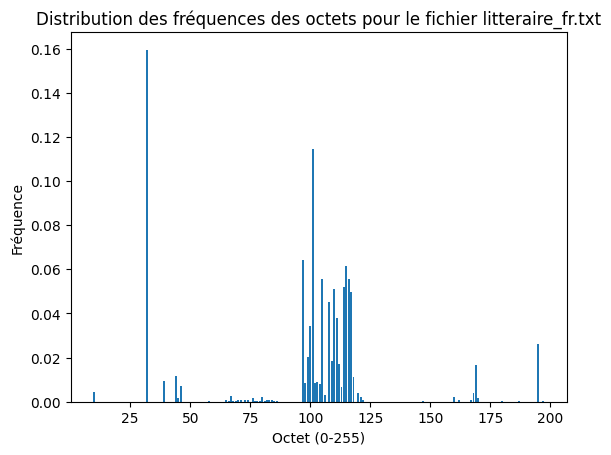

=== Analyse de litteraire_fr.txt ===
  taille_octets: 5092
  entropie: 4.422
  economie_max_h0: 44.73
  longueur_plage_max: 2
  longueur_plage_moy: 1.02
  couverture_motifs_4grams: 100.0


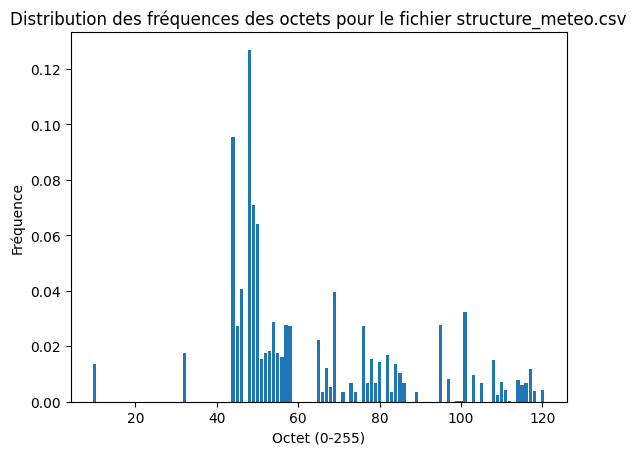

=== Analyse de structure_meteo.csv ===
  taille_octets: 26515
  entropie: 4.969
  economie_max_h0: 37.89
  longueur_plage_max: 3
  longueur_plage_moy: 1.06
  couverture_motifs_4grams: 100.0


In [310]:
def analyser_fichier(chemin_fichier: str) -> dict:
    with open(chemin_fichier, 'rb') as f:
        donnees = f.read()
    
    n_octets = len(donnees)
    if n_octets == 0:
        return {}

    # 1. Entropie du fichier (H0)
    comptage_octets = Counter(donnees)
    probs = np.array(list(comptage_octets.values())) / n_octets
    h0 = -np.sum(probs * np.log2(probs))

    # 2. Analyse des plages consécutives (RLE)
    plages = []
    longueur_courante = 1
    for i in range(1, n_octets):
        if donnees[i] == donnees[i-1]:
            longueur_courante += 1
        else:
            plages.append(longueur_courante)
            longueur_courante = 1
    plages.append(longueur_courante)

    # 3. Taux de couverture des motifs de longueur >= 4 (LZ77)
    motifs_4 = Counter([donnees[i:i+4] for i in range(n_octets - 3)])
    octets_repetes = sum(c * 4 for _, c in motifs_4.items() if c > 1)
    taux_couverture_lz = min(100.0, (octets_repetes / n_octets) * 100)

    # 4. Limites théoriques de compression (en octets)
    taille_min_h0 = (h0 * n_octets) / 8

    # 5. Distribution des fréquences des caractères (plot)
    frequences = {octet: count / n_octets for octet, count in comptage_octets.items()}
    plt.bar(frequences.keys(), frequences.values())
    plt.title(f"Distribution des fréquences des octets pour le fichier {chemin_fichier}")
    plt.xlabel("Octet (0-255)")
    plt.ylabel("Fréquence")
    plt.show()

    return {
        "taille_octets": n_octets,
        "entropie": round(h0, 3),
        "economie_max_h0": round((1 - taille_min_h0 / n_octets) * 100, 2),
        "longueur_plage_max": max(plages),
        "longueur_plage_moy": round(np.mean(plages), 2),
        "couverture_motifs_4grams": round(taux_couverture_lz, 2)
    }

sizes_octets = []
fichiers = ["code_source_python.py", "litteraire_fr.txt", "structure_meteo.csv"]
for f in fichiers:
    res = analyser_fichier(f)
    size_octets = res.get("taille_octets", 0)
    sizes_octets.append(size_octets)
    print(f"=== Analyse de {f} ===")
    for k, v in res.items():
        print(f"  {k}: {v}")

In [311]:
# Code du cours venant de "https://github.com/gabilodeau/INF8770/blob/master/Codage%20Huffman.ipynb" adapté en classe python

class Huffman():
    def __init__(self):
        return

    def build_tree(self, message):
        #Liste qui sera modifié jusqu'à ce qu'elle contienne seulement la racine de l'arbre
        ArbreSymb =[[message[0], message.count(message[0]), Node(message[0])]]
        #dictionnaire obtenu à partir de l'arbre.
        dictionnaire = [[message[0], '']]
        nbsymboles = 1

        #Recherche des feuilles de l'arbre
        for i in range(1,len(message)):
            if not list(filter(lambda x: x[0] == message[i], ArbreSymb)):
                ArbreSymb += [[message[i], message.count(message[i]),Node(message[i])]]
                dictionnaire += [[message[i], '']]
                nbsymboles += 1

        longueurOriginale = np.ceil(np.log2(nbsymboles))*len(message)

        OccSymb = ArbreSymb.copy()
        ArbreSymb = sorted(ArbreSymb, key=lambda x: x[1])

        while len(ArbreSymb) > 1:
            #Fusion des noeuds de poids plus faibles
            symbfusionnes = ArbreSymb[0][0] + ArbreSymb[1][0]
            #Création d'un nouveau noeud
            noeud = Node(symbfusionnes)
            temp = [symbfusionnes, ArbreSymb[0][1] + ArbreSymb[1][1], noeud]
            #Ajustement de l'arbre pour connecter le nouveau avec ses parents
            ArbreSymb[0][2].parent = noeud
            ArbreSymb[1][2].parent = noeud
            #Enlève les noeuds fusionnés de la liste de noeud à fusionner.
            del ArbreSymb[0:2]
            #Ajout du nouveau noeud à la liste et tri.
            ArbreSymb += [temp]
            #Pour affichage de l'arbre ou des sous-branches
            # print('\nArbre actuel:\n\n')
            # for i in range(len(ArbreSymb)):
            #     if len(ArbreSymb[i][0]) > 1:
            #         print(RenderTree(ArbreSymb[i][2], style=AsciiStyle()).by_attr())
            ArbreSymb = sorted(ArbreSymb, key=lambda x: x[1])

        ArbreCodes = Node('')
        noeud = ArbreCodes
        #print([node.name for node in PreOrderIter(ArbreSymb[0][2])])
        parcoursprefix = [node for node in PreOrderIter(ArbreSymb[0][2])]
        parcoursprefix = parcoursprefix[1:len(parcoursprefix)] #ignore la racine

        Prevdepth = 0 #pour suivre les mouvements en profondeur dans l'arbre
        for node in parcoursprefix:  #Liste des noeuds
            if Prevdepth < node.depth: #On va plus profond dans l'arbre, on met un 0
                temp = Node(noeud.name + '0')
                noeud.children = [temp]
                if node.children: #On avance le "pointeur" noeud si le noeud ajouté a des enfants.
                    noeud = temp
            elif Prevdepth == node.depth: #Même profondeur, autre feuille, on met un 1
                temp = Node(noeud.name + '1')
                noeud.children = [noeud.children[0], temp]  #Ajoute le deuxième enfant
                if node.children: #On avance le "pointeur" noeud si le noeud ajouté a des enfants.
                    noeud = temp
            else:
                for i in range(Prevdepth-node.depth): #On prend une autre branche, donc on met un 1
                    noeud = noeud.parent #On remontre dans l'arbre pour prendre la prochaine branche non explorée.
                temp = Node(noeud.name + '1')
                noeud.children = [noeud.children[0], temp]
                if node.children:
                    noeud = temp

            Prevdepth = node.depth

        ArbreSymbList = [node for node in PreOrderIter(ArbreSymb[0][2])]
        ArbreCodeList = [node for node in PreOrderIter(ArbreCodes)]

        for i in range(len(ArbreSymbList)):
            if ArbreSymbList[i].is_leaf: #Génère des codes pour les feuilles seulement
                temp = list(filter(lambda x: x[0] == ArbreSymbList[i].name, dictionnaire))
                if temp:
                    indice = dictionnaire.index(temp[0])
                    dictionnaire[indice][1] = ArbreCodeList[i].name

        return dictionnaire, longueurOriginale

    def generate_codes(self, message, dictionnaire):
        messageCode = []
        longueur = 0
        for i in range(len(message)):
            substitution = list(filter(lambda x: x[0] == message[i], dictionnaire))
            messageCode += [substitution[0][1]]
            longueur += len(substitution[0][1])
        return messageCode, longueur

    def decode_message(self, message_code, dictionnaire):
        # Inverse le dictionnaire pour décoder
        inverse_dict = {code: char for char, code in dictionnaire}
        decoded_message = []
        current_code = ''
        for code in message_code:
            current_code += code
            if current_code in inverse_dict:
                decoded_message.append(inverse_dict[current_code])
                current_code = ''
        return decoded_message

In [312]:
class Golomb():
    def __init__(self):
        return

    def encode_bit(self, n, m):
        q = n // m
        r = n % m

        # Unary encoding pour le quotient
        unary_code = '1' * q + '0'

        # Binary encoding pour le reste
        b = math.ceil(math.log2(m))
        if (2**b - m) > r:
            binary_code = format(r, f'0{b-1}b')  # b-1 bits
        else:
            binary_code = format(r + (2**b - m), f'0{b}b')  # b bits

        return unary_code + binary_code

    def encode(self, data, m):
        encoded_data = ''
        for n in data:
            encoded_data += self.encode_bit(n, m)
        return encoded_data

    def decode(self, encoded_data, m):
        decoded_data = []
        i = 0
        while i < len(encoded_data):
            # On décode le quotient en comptant les '1' jusqu'au premier '0' qu'on skip
            q = 0
            while i < len(encoded_data) and encoded_data[i] == '1':
                q += 1
                i += 1
            i += 1
            if i >= len(encoded_data):
                break

            # On décode le reste en lisant les b bits suivants
            b = math.ceil(math.log2(m))
            r_bits = encoded_data[i:i + b - 1]
            if not r_bits:
                break
            r_value = int(r_bits, 2)
            
            # Check if we need to read b bits instead
            if r_value >= (2**b - m):
                # Re-read as b bits
                r_bits = encoded_data[i:i + b]
                if len(r_bits) < b:
                    break
                r_value = int(r_bits, 2)
                r_value -= (2**b - m)
                i += b
            else:
                i += b - 1
            
            n = q * m + r_value
            decoded_data.append(n)

        return decoded_data

    def optimal_m(self, data):
        """Trouve la valeur de m qui minimise la longueur binaire codée."""
        best_m = 1
        best_len = float('inf')
        # Recherche empirique sur une plage raisonnable
        for m_cand in range(1, 64):
            encoded = self.encode(data, m_cand)
            if len(encoded) < best_len:
                best_len = len(encoded)
                best_m = m_cand
        return best_m

In [313]:
# Avant d'encoder le message avec Golomb, on utilise un codage prédictif zigzag pour transformer le message en une séquence d'entiers.
# Ici on utilise la différence entre chaque octet et son précédent, pour centrer la distribution des valeurs autour de zéro, ce qui
# donne de bons résultats couplé avec le codage de Golomb. Le mapping zigzag est important car un codage prédictif simple modulo 255
# donne une très mauvaise distribution des valeurs pour du golomb, on veut donc se rapprocher le plus d'une distribution géométrique centrée sur zéro.

def map_zigzag(e: int) -> int:
    """Mappe un entier signé e vers un entier non négatif k."""
    return 2 * e if e >= 0 else -2 * e - 1

def unmap_zigzag(k: int) -> int:
    return k // 2 if k % 2 == 0 else -(k + 1) // 2

def predictive_coding_zigzag(data):
    """Codage prédictif DPCM d'ordre 1 avec mapping ZigZag."""
    if not data:
        return []
    residuals = [data[0]]
    for i in range(1, len(data)):
        diff = data[i] - data[i-1]
        residuals.append(map_zigzag(diff))
    return residuals

def decode_predictive_zigzag(zigzag_residuals: list[int]) -> list[int]:
    """Reconstruit la séquence de données originale à partir des résidus ZigZag."""
    if not zigzag_residuals:
        return []
    
    # Le premier élément est conservé tel quel
    data = [zigzag_residuals[0]]
    
    # Reconstitution pas à pas : data[i] = data[i-1] + diff
    for i in range(1, len(zigzag_residuals)):
        diff = unmap_zigzag(zigzag_residuals[i])
        data.append(data[-1] + diff)
        
    return data

In [314]:
# On peut maintenant combiner le codage prédictif avec le codage de Golomb pour encoder et décoder les données.

def encode_with_predictive_golomb(data):
    # Appliquer le codage prédictif
    differences = predictive_coding_zigzag(data)

    # Trouver la valeur optimale de m pour le codage de Golomb
    golomb = Golomb()
    optimal_m = golomb.optimal_m(differences)

    # Encoder les différences avec le codage de Golomb
    encoded_data = golomb.encode(differences, optimal_m)

    return encoded_data, optimal_m

def decode_with_predictive_golomb_zigzag(encoded_data, optimal_m):
    golomb = Golomb()
    # Décoder les données encodées avec le codage de Golomb
    decoded_zigzag_residuals = golomb.decode(encoded_data, optimal_m)

    # Reconstruire les octets originaux à partir des résidus ZigZag
    original_data = decode_predictive_zigzag(decoded_zigzag_residuals)
    
    return original_data

In [315]:
# On peut maintenant encoder chaque fichier avec d'abord Huffman, puis Golomb prédictif, et vérifier que le décodage nous ramène
# aux données originales.

sizes_encoded_huffman = []
sizes_dictionaries_huffman = []
sizes_dictionaries_golomb = []
sizes_encoded_golomb = []
sizes_encoded_golomb_huffman = []
for f in fichiers:
    with open(f, 'rb') as file:
        original_data = list(file.read())

    # Encodage avec Huffman
    huffman = Huffman()
    dictionnaire, _ = huffman.build_tree(original_data)
    sizes_dictionaries_huffman.append(len(dictionnaire))
    encoded_huffman, longueur_huffman = huffman.generate_codes(original_data, dictionnaire)
    sizes_encoded_huffman.append(longueur_huffman)
    decoded_huffman = huffman.decode_message(encoded_huffman, dictionnaire)

    # Encodage avec Golomb prédictif
    encoded_golomb, optimal_m = encode_with_predictive_golomb(original_data)
    longueur_golomb = len(encoded_golomb)
    sizes_encoded_golomb.append(longueur_golomb)

    # Ajout d'un huffman après le golomb pour voir si on peut améliorer le taux de compression
    golomb_huffman = Huffman()
    dictionnaire_golomb, _ = golomb_huffman.build_tree(encoded_golomb)
    sizes_dictionaries_golomb.append(len(dictionnaire_golomb))
    encoded_golomb_huffman, longueur_golomb_huffman = golomb_huffman.generate_codes(encoded_golomb, dictionnaire_golomb)
    sizes_encoded_golomb_huffman.append(longueur_golomb_huffman)
    decoded_golomb_huffman = golomb_huffman.decode_message(encoded_golomb_huffman, dictionnaire_golomb)

    # Décodage avec Golomb prédictif
    decoded_golomb = decode_with_predictive_golomb_zigzag(encoded_golomb, optimal_m)

    # Vérification que le décodage nous ramène aux données originales
    assert original_data == decoded_huffman, f"Erreur de décodage Huffman pour le fichier {f}"
    assert original_data == decoded_golomb, f"Erreur de décodage pour le fichier {f}"



=== Distribution des résidus ZigZag après codage prédictif ===

code_source_python.py:
  Mean residual: 44.62
  Median residual: 19.00
  Max residual: 245
  Unique values: 175

litteraire_fr.txt:
  Mean residual: 69.60
  Median residual: 30.00
  Max residual: 330
  Unique values: 163

structure_meteo.csv:
  Mean residual: 22.02
  Median residual: 13.00
  Max residual: 219
  Unique values: 91



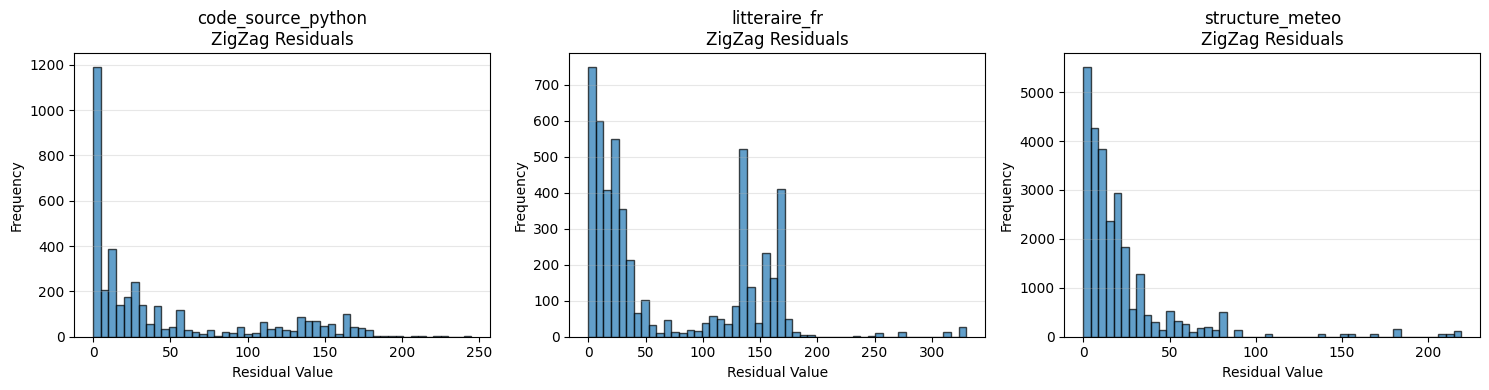

In [316]:
# Plots des distributions des résidus ZigZag après codage prédictif

print("\n=== Distribution des résidus ZigZag après codage prédictif ===\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, f in enumerate(fichiers):
    with open(f, 'rb') as file:
        original_data = list(file.read())
    
    # Appliquer le codage prédictif ZigZag
    residuals = predictive_coding_zigzag(original_data)
    
    freq_residuals = Counter(residuals)
    mean_residual = np.mean(residuals)
    median_residual = np.median(residuals)
    
    print(f"{f}:")
    print(f"  Mean residual: {mean_residual:.2f}")
    print(f"  Median residual: {median_residual:.2f}")
    print(f"  Max residual: {max(residuals)}")
    print(f"  Unique values: {len(freq_residuals)}")
    print()
    
    ax = axes[idx]
    residuals_sorted = sorted(residuals)
    ax.hist(residuals_sorted, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f"{f.split('.')[0]}\nZigZag Residuals")
    ax.set_xlabel("Residual Value")
    ax.set_ylabel("Frequency")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


=== Analyse détaillée incluant overhead du dictionnaire ===

code_source_python.py:
  Original:                        3844 octets (100.0%)
  Huffman alone:                2383.00 octets ( 62.0%)
  Golomb alone:                 3279.88 octets ( 85.3%)
  Golomb + Huffman:             3559.88 octets ( 92.6%)
    └─ Golomb encoded:          3279.88 octets
    └─ Huffman on Golomb:       3279.88 octets
    └─ Both dictionaries:        280.00 octets

litteraire_fr.txt:
  Original:                        5092 octets (100.0%)
  Huffman alone:                3077.50 octets ( 60.4%)
  Golomb alone:                 4833.88 octets ( 94.9%)
  Golomb + Huffman:             5089.88 octets (100.0%)
    └─ Golomb encoded:          4833.88 octets
    └─ Huffman on Golomb:       4833.88 octets
    └─ Both dictionaries:        256.00 octets

structure_meteo.csv:
  Original:                       26515 octets (100.0%)
  Huffman alone:               16761.38 octets ( 63.2%)
  Golomb alone:                

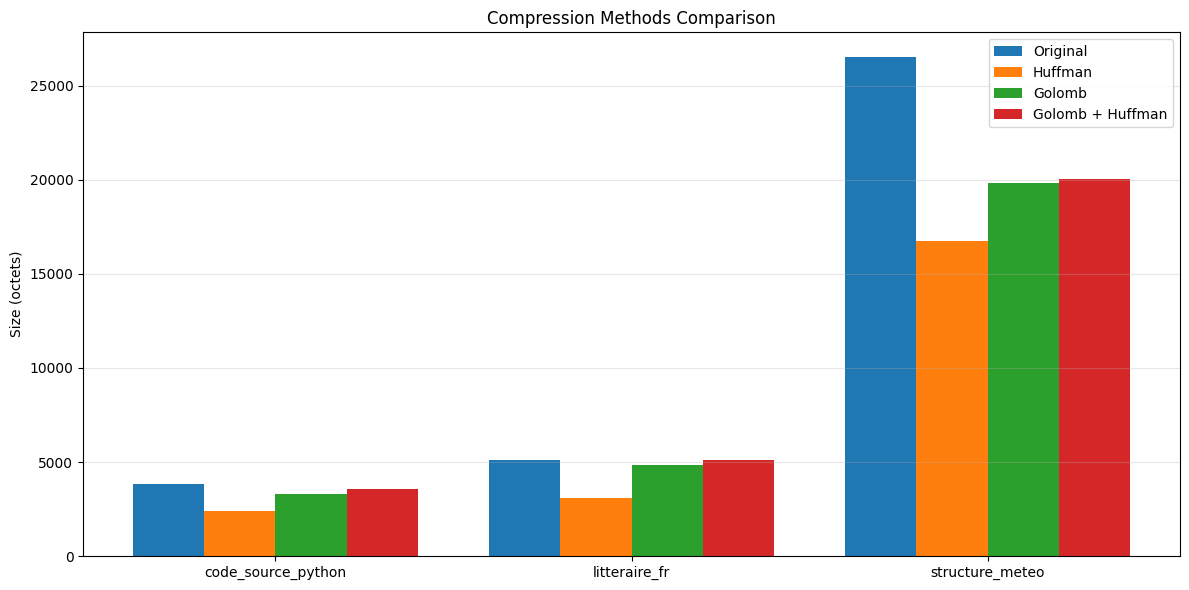

In [317]:
# Plots et statistiques pour un résumé comparatif des méthodes de compression utilisées sur les fichiers analysés.

print("\n=== Analyse détaillée incluant overhead du dictionnaire ===\n")

for i, f in enumerate(fichiers):
    original_size = sizes_octets[i]
    huffman_encoded = sizes_encoded_huffman[i] / 8
    dict_entries_huffman = sizes_dictionaries_huffman[i]
    dict_overhead_huffman = dict_entries_huffman * 4
    huffman_total = huffman_encoded + dict_overhead_huffman
    
    golomb_size = sizes_encoded_golomb[i] / 8
    
    golomb_huffman_encoded = sizes_encoded_golomb_huffman[i] / 8
    dict_entries_golomb = sizes_dictionaries_golomb[i]
    dict_overhead_golomb = dict_entries_golomb * 4
    golomb_huffman_total = golomb_huffman_encoded + dict_overhead_huffman + dict_overhead_golomb
    
    print(f"{f}:")
    print(f"  Original:                    {original_size:8.0f} octets (100.0%)")
    print(f"  Huffman alone:               {huffman_total:8.2f} octets ({huffman_total/original_size*100:5.1f}%)")
    print(f"  Golomb alone:                {golomb_size:8.2f} octets ({golomb_size/original_size*100:5.1f}%)")
    print(f"  Golomb + Huffman:            {golomb_huffman_total:8.2f} octets ({golomb_huffman_total/original_size*100:5.1f}%)")
    print(f"    └─ Golomb encoded:         {golomb_size:8.2f} octets")
    print(f"    └─ Huffman on Golomb:      {golomb_huffman_encoded:8.2f} octets")
    print(f"    └─ Both dictionaries:      {dict_overhead_huffman + dict_overhead_golomb:8.2f} octets")
    print()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(fichiers))
width = 0.2

original = sizes_octets
huffman_total = [sizes_encoded_huffman[i]/8 + sizes_dictionaries_huffman[i]*4 for i in range(len(fichiers))]
golomb = [sizes_encoded_golomb[i]/8 for i in range(len(fichiers))]
golomb_huffman = [sizes_encoded_golomb_huffman[i]/8 + sizes_dictionaries_huffman[i]*4 + sizes_dictionaries_golomb[i]*4 for i in range(len(fichiers))]

ax.bar(x - 1.5*width, original, width, label='Original')
ax.bar(x - 0.5*width, huffman_total, width, label='Huffman')
ax.bar(x + 0.5*width, golomb, width, label='Golomb')
ax.bar(x + 1.5*width, golomb_huffman, width, label='Golomb + Huffman')

ax.set_ylabel('Size (octets)')
ax.set_title('Compression Methods Comparison')
ax.set_xticks(x)
ax.set_xticklabels([f.split('.')[0] for f in fichiers])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [318]:
# Test d'une meilleure solution pour exploiter les motifs répétitifs avec LZ77 optimisé, sans Huffman après.
class LZ77Optimized:
    """LZ77 avec codage variable-length optimisé (sans Huffman après)."""
    def __init__(self, window_size=32768, lookahead_size=258):
        self.window_size = window_size
        self.lookahead_size = lookahead_size
    
    def find_longest_match(self, data, pos):
        end_of_buffer = min(pos + self.lookahead_size, len(data))
        search_start = max(0, pos - self.window_size)
        longest_match_distance = 0
        longest_match_length = 0
        
        for i in range(search_start, pos):
            match_length = 0
            while (match_length < end_of_buffer - pos and 
                   data[i + match_length] == data[pos + match_length]):
                match_length += 1
            
            if match_length > longest_match_length:
                longest_match_length = match_length
                longest_match_distance = pos - i
        
        return longest_match_distance, longest_match_length
    
    def encode(self, data):
        encoded = []
        pos = 0
        while pos < len(data):
            distance, length = self.find_longest_match(data, pos)
            if length >= 3:
                encoded.append((distance, length))
                pos += length
            else:
                encoded.append((0, data[pos]))
                pos += 1
        return encoded
    
    def decode(self, encoded):
        decoded = []
        for distance, value in encoded:
            if distance == 0:
                decoded.append(value)
            else:
                start_pos = len(decoded) - distance
                for i in range(value):
                    decoded.append(decoded[start_pos + i])
        return decoded
    
    def encode_to_bytes(self, data):
        """Encode avec codage variable-length optimisé."""
        encoded_pairs = self.encode(data)
        bit_string = ''
        
        for distance, value in encoded_pairs:
            if distance == 0:
                # Littéral: flag 0 + 8 bits du byte
                bit_string += '0' + format(value, '08b')
            else:
                # Match: flag 1 + distance (variable) + longueur (variable)
                bit_string += '1'
                
                bit_string += format(distance, '015b')
                
                bit_string += format(value, '08b')
        
        # Convertir en bytes
        while len(bit_string) % 8 != 0:
            bit_string += '0'
        
        byte_array = bytes(int(bit_string[i:i+8], 2) for i in range(0, len(bit_string), 8))
        return byte_array, len(encoded_pairs)
    
    def decode_from_bytes(self, data, num_pairs):
        bit_string = ''.join(format(b, '08b') for b in data)
        encoded_pairs = []
        i = 0
        
        while len(encoded_pairs) < num_pairs and i < len(bit_string):
            if bit_string[i] == '0':
                i += 1
                byte_val = int(bit_string[i:i+8], 2)
                encoded_pairs.append((0, byte_val))
                i += 8
            else:
                i += 1
                distance = int(bit_string[i:i+15], 2)
                i += 15
                length = int(bit_string[i:i+8], 2)
                i += 8
                encoded_pairs.append((distance, length))
        
        return self.decode(encoded_pairs)

code_source_python.py:
  Taille originale:               3844 B
  ├─ Huffman:                     2383 B ( 62.0%)
  └─ LZ77 Optimisé:               1743 B ( 45.3%)
  
Amélioration:            -     640 B ( 26.9% mieux)
Matches: 954 | Littéraux: 0

litteraire_fr.txt:
  Taille originale:               5092 B
  ├─ Huffman:                     3078 B ( 60.4%)
  └─ LZ77 Optimisé:               3995 B ( 78.5%)
  
Expansion:               +     918 B ( 29.8% pire)
Matches: 1909 | Littéraux: 0

structure_meteo.csv:
  Taille originale:              26515 B
  ├─ Huffman:                    16761 B ( 63.2%)
  └─ LZ77 Optimisé:               7420 B ( 28.0%)
  
Amélioration:            -    9341 B ( 55.7% mieux)
Matches: 2763 | Littéraux: 0



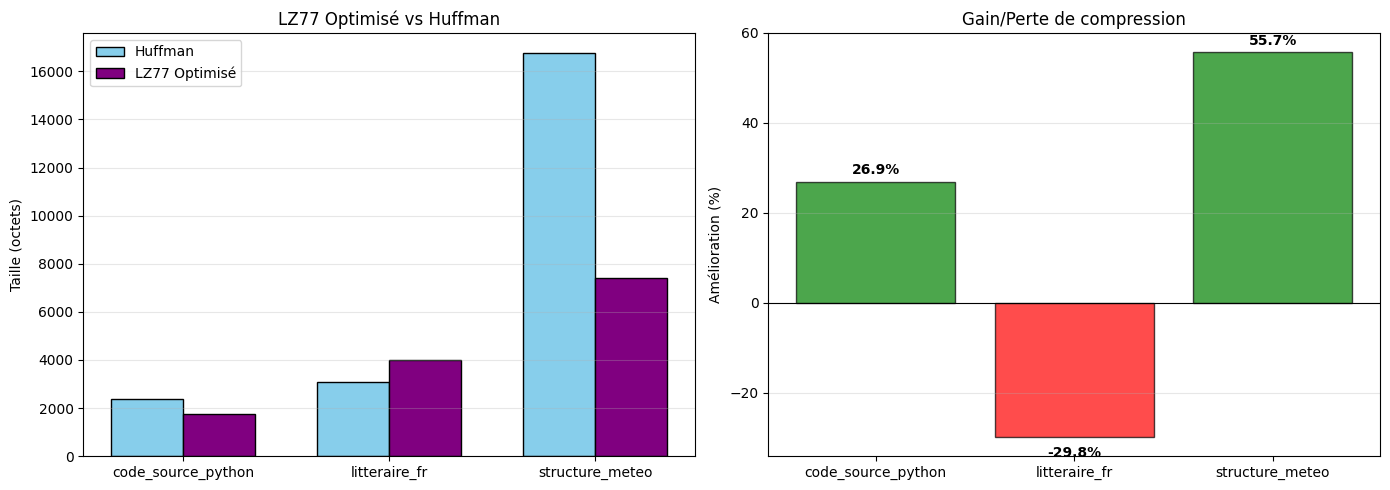


CONCLUSION

Résultats:

1. Huffman gagne car les fichiers ont une grande entropie

2. LZ77/LZW peuvent échouer car:
   - Fichiers trop petits pour le dictionnaire (overhead > gain)
   - Pas assez de longues séquences répétées
   - Double compression (LZ77 → Huffman) crée overhead

Meilleure stratégie par type de fichier:
   - Python (code):        LZ77 > Huffman (si plus grand, beaucoup de répétitions d'espaces notamment avec l'indentation python)
   - Texte:                Huffman = LZ77 (peu de répétitions, texte en français avec une grande variété de caractères)
   - CSV:                  LZ77 > Huffman (valeurs répétées)



In [ ]:
# Test LZ77 Optimisé vs Huffman

optimized_results = {}

for f in fichiers:
    with open(f, 'rb') as file:
        original_data = list(file.read())
    
    file_size = len(original_data)
    huffman_size = sizes_encoded_huffman[fichiers.index(f)]/8 + sizes_dictionaries_huffman[fichiers.index(f)]*4
    
    # LZ77 Optimisé
    lz77_opt = LZ77Optimized()
    encoded_bytes, num_pairs = lz77_opt.encode_to_bytes(original_data)
    lz77_opt_size = len(encoded_bytes) + 4  # +4 pour stocker num_pairs
    lz77_opt_percent = lz77_opt_size / file_size * 100
    
    # Vérifier décodage
    decoded = lz77_opt.decode_from_bytes(encoded_bytes, num_pairs)
    assert decoded == original_data, f"Erreur décodage LZ77 Opt pour {f}"
    
    num_matches = sum(1 for _, v in lz77_opt.encode(original_data) if v >= 3)
    num_literals = sum(1 for _, v in lz77_opt.encode(original_data) if v < 3)
    
    improvement = huffman_size - lz77_opt_size
    improvement_pct = (improvement / huffman_size) * 100
    
    optimized_results[f] = {
        'huffman': huffman_size,
        'lz77_opt': lz77_opt_size,
        'improvement': improvement,
        'improvement_pct': improvement_pct
    }
    
    print(f"{f}:")
    print(f"  Taille originale:           {file_size:8.0f} B")
    print(f"  ├─ Huffman:                 {huffman_size:8.0f} B ({huffman_size/file_size*100:5.1f}%)")
    print(f"  └─ LZ77 Optimisé:           {lz77_opt_size:8.0f} B ({lz77_opt_percent:5.1f}%)")
    print(f"  ")
    
    if improvement > 0:
        print(f"Amélioration:            -{improvement:8.0f} B ({improvement_pct:5.1f}% mieux)")
    else:
        print(f"Expansion:               +{-improvement:8.0f} B ({abs(improvement_pct):5.1f}% pire)")
    
    print(f"Matches: {num_matches} | Littéraux: {num_literals}")
    print()

# Graphique final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

files_short = [f.split('.')[0] for f in fichiers]
x = np.arange(len(files_short))
width = 0.35

huffman_sizes = [optimized_results[f]['huffman'] for f in fichiers]
lz77_opt_sizes = [optimized_results[f]['lz77_opt'] for f in fichiers]

axes[0].bar(x - width/2, huffman_sizes, width, label='Huffman', color='skyblue', edgecolor='black')
axes[0].bar(x + width/2, lz77_opt_sizes, width, label='LZ77 Optimisé', color='purple', edgecolor='black')
axes[0].set_ylabel('Taille (octets)')
axes[0].set_title('LZ77 Optimisé vs Huffman')
axes[0].set_xticks(x)
axes[0].set_xticklabels(files_short)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Amélioration
improvements = [optimized_results[f]['improvement_pct'] for f in fichiers]
colors = ['green' if imp > 0 else 'red' for imp in improvements]

axes[1].bar(x, improvements, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Amélioration (%)')
axes[1].set_title('Gain/Perte de compression')
axes[1].set_xticks(x)
axes[1].set_xticklabels(files_short)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(improvements):
    axes[1].text(i, v + (1 if v > 0 else -2), f'{v:.1f}%', ha='center', 
                va='bottom' if v > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print("""
Résultats:

1. Huffman est difficile à battre car les fichiers ont une grande entropie

2. LZ77/LZW peuvent échouer car:
   - Fichiers trop petits pour le dictionnaire (overhead > gain)
   - Pas assez de longues séquences répétées
   - Double compression (LZ77 → Huffman) crée overhead

Meilleure stratégie par type de fichier:
   - Python (code):        LZ77 > Huffman (si plus grand, beaucoup de répétitions d'espaces notamment avec l'indentation python)
   - Texte:                Huffman = LZ77 (peu de répétitions, texte en français avec une grande variété de caractères)
   - CSV:                  LZ77 > Huffman (valeurs répétées)
""")